# 04 · KD por atención, backbone descongelado

*Attention transfer*: en vez de alinear features, alinea el mapa de atención espacial.

Al colapsar la dimensión de canal **no necesita proyección**: no hay nada que aprender para traducir entre arquitecturas ni escala que compensar. Es la variante agnóstica a la arquitectura por construcción, y la más indicada cuando docente y estudiante son de familias distintas.

In [ ]:
# En Kaggle clona el repo; en local no hace nada.
import os
import subprocess
import sys
from pathlib import Path

if Path("/kaggle").exists():
    from kaggle_secrets import UserSecretsClient

    # /tmp y no /kaggle/working: esa carpeta se guarda como salida del notebook
    CLON = "/tmp/ButterflyModeling"
    AYUDA = "!f() { echo username=x-access-token; echo password=$GITHUB_TOKEN; }; f"
    os.environ["GITHUB_TOKEN"] = UserSecretsClient().get_secret("GITHUB_TOKEN")
    if not Path(CLON).exists():
        subprocess.run(["git", "-c", f"credential.helper={AYUDA}", "clone",
                        "https://github.com/CCSandoval/ButterflyModeling.git", CLON], check=True)
    sys.path.insert(0, CLON)
    os.chdir(CLON)
    print("clon en", CLON, "·", subprocess.run(
        ["git", "log", "-1", "--format=%h %s"], cwd=CLON,
        capture_output=True, text=True).stdout.strip())

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "corpus.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import tensorflow as tf

from scripts import corpus, evalStats
from scripts import modelRegistry as registro
from scripts.architectures import buildModel, descongelarCola, preprocessFn
from scripts.entrenamiento import callbacksEntrenamiento
from scripts.dataPipeline import buildAugmenter, loadSplit, preparar, prepararCrudo
from scripts.distillation import DestiladorAtencion
from scripts.vizStyle import SERIE_1, SERIE_2, applyStyle, plotConfusionMatrix

estudianteInfo = registro.readJson(registro.OUTPUTS_DIR / "student.json")
if estudianteInfo is None:
    raise FileNotFoundError(
        "Falta outputs/student.json — corre antes 01_student/05_comparacion_estudiante.ipynb")

ARQUITECTURA = estudianteInfo["architecture"]
RUN_NAME = f"kd-atencion-{ARQUITECTURA.replace('_', '-')}"
NOTAS = "KD de respuesta + attention transfer, backbone descongelado"
ROL = "destilado"
PROMOVER = False

FRACCION_DESCONGELADA = 0.30
TEMPERATURA = 4.0
ALFA = 0.7
# el mapa normalizado vale ~1e-2; beta lo lleva a ~10% de la pérdida total
BETA_ATENCION = 60.0

TAMANO = (320, 320)
LOTE = 32
EPOCAS = 100
PACIENCIA = 8
TASA_APRENDIZAJE = 1e-4
SEMILLA = 42

tf.keras.utils.set_random_seed(SEMILLA)
corpus.materializar()

RUN_ID = registro.buildRunId(RUN_NAME)
RUN_DIR = registro.createRunDir(RUN_ID)
IMGS = RUN_DIR / "imgs"

print(f"run_id : {RUN_ID}")
print(f"TF     : {tf.__version__} · dispositivos: "
      f"{[d.device_type for d in tf.config.list_physical_devices()]}")

run_id : 20261003T123506Z_kd-atencion-mobilenet-v3-small
TF     : 2.19.1 · dispositivos: ['CPU']


## 1 · Docente

Sale de `outputs/teacher.json`, escrito por `02_teacher/06`.

In [3]:
docenteInfo = registro.readJson(registro.OUTPUTS_DIR / "teacher.json")
if docenteInfo is None:
    raise FileNotFoundError("Falta outputs/teacher.json — corre antes 02_teacher/06_comparacion_docente.ipynb")

ARQUITECTURA_DOCENTE = docenteInfo["architecture"]
docente = tf.keras.models.load_model(
    registro.rutaModelo(docenteInfo["run_id"])
)
docente.trainable = False

pd.Series({
    "run_id": docenteInfo["run_id"],
    "arquitectura": ARQUITECTURA_DOCENTE,
    "test_accuracy": round(docenteInfo["test_accuracy"], 4),
    "test_macro_f1": round(docenteInfo["test_macro_f1"], 4),
    "parametros": docente.count_params(),
}).to_frame("docente")

,docente
run_id,20260913T005433Z_efficientnet-v2-s
arquitectura,efficientnet_v2_s
test_accuracy,0.9142
test_macro_f1,0.9135
parametros,21165231


## 2 · Datos

`train` sale crudo (0-255) y aumentado una sola vez; el `Destilador` preprocesa por dentro para cada modelo. `validate`/`test` van preprocesados para el estudiante, sin barajar.

In [4]:
preprocessDocente = preprocessFn(ARQUITECTURA_DOCENTE)
preprocessEstudiante = preprocessFn(ARQUITECTURA)
augmentador = buildAugmenter()

dsTrainCrudo, clases = loadSplit("dataset/train", TAMANO, LOTE)
dsValCrudo, _ = loadSplit("dataset/validate", TAMANO, LOTE, shuffle=False)
dsTestCrudo, _ = loadSplit("dataset/test", TAMANO, LOTE, shuffle=False)

dsTrain = prepararCrudo(dsTrainCrudo, augmentador)
dsValDestilacion = dsValCrudo.prefetch(tf.data.AUTOTUNE)   # crudo: el Destilador preprocesa por dentro
dsVal = preparar(dsValCrudo, preprocessEstudiante)
dsTest = preparar(dsTestCrudo, preprocessEstudiante)

print(f"{len(clases)} clases")

Found 7214 files belonging to 79 classes.
Found 1038 files belonging to 79 classes.
Found 2061 files belonging to 79 classes.
79 clases


## 3 · Estudiante

In [5]:
estudiante = buildModel(ARQUITECTURA, len(clases))
infoFt = descongelarCola(estudiante, FRACCION_DESCONGELADA)
print(infoFt)

pd.Series({
    "estudiante": ARQUITECTURA,
    "parametros_estudiante": estudiante.count_params(),
    "parametros_docente": docente.count_params(),
    "razon_compresion": round(docente.count_params() / estudiante.count_params(), 1),
}).to_frame("valor")

/opt/miniconda3/envs/semillero/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


{'capas_backbone': 157, 'capas_descongeladas': 38, 'parametros_entrenables': 1200631}


,valor
estudiante,mobilenet_v3_small
parametros_estudiante,1412543
parametros_docente,21165231
razon_compresion,15.0


## 4 · Pesos de clase

In [6]:
pesosClase = corpus.classWeights()
pd.Series(
    {clases[i]: round(p, 3) for i, p in pesosClase.items()}
).sort_values(ascending=False).head(8).to_frame("peso")

,peso
autochton_itylus,3.149
taygetis_sylvia,3.149
cissia_confusa,3.149
pseudodebis_puritana,3.044
pyrgus_adepta,2.946
pteronymia_latilla,2.124
euselasia_mys,2.075
pteronymia_aletta,1.985


## 5 · Entrenamiento con destilación

`val_loss` es la CE del estudiante, no la pérdida de destilación: así el EarlyStopping monitorea lo mismo que en los notebooks de candidatos. El docente corre en inferencia en cada paso — no se puede precomputar, la vista aumentada cambia cada época.

In [7]:
from tensorflow.keras.optimizers import Adam

destilador = DestiladorAtencion(
    docente, estudiante, preprocessDocente, preprocessEstudiante,
    TEMPERATURA, ALFA, BETA_ATENCION,
)
destilador.compile(optimizer=Adam(learning_rate=TASA_APRENDIZAJE))

# reanudables: un corte cuesta una época, no el run entero
callbacks = callbacksEntrenamiento(RUN_NAME, PACIENCIA)

inicio = datetime.now(timezone.utc)
ajuste = destilador.fit(
    dsTrain,
    validation_data=dsValDestilacion,
    epochs=EPOCAS,
    callbacks=callbacks,
    class_weight=pesosClase,
    verbose=2,
)
fin = datetime.now(timezone.utc)

historia = {k: [float(v) for v in vs] for k, vs in ajuste.history.items()}
print(f"\n{len(historia['loss'])} épocas en {(fin - inicio).total_seconds() / 60:.1f} min")

Epoch 1/100
226/226 - 481s - 2s/step - accuracy: 0.0272 - loss: 7.7621 - loss_atencion: 0.0093 - val_accuracy: 0.1320 - val_loss: 3.7682 - val_loss_atencion: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/100
226/226 - 511s - 2s/step - accuracy: 0.0731 - loss: 6.9599 - loss_atencion: 0.0083 - val_accuracy: 0.2890 - val_loss: 3.0141 - val_loss_atencion: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/100
226/226 - 517s - 2s/step - accuracy: 0.1212 - loss: 6.4267 - loss_atencion: 0.0078 - val_accuracy: 0.3555 - val_loss: 2.6209 - val_loss_atencion: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/100
226/226 - 514s - 2s/step - accuracy: 0.1888 - loss: 5.9627 - loss_atencion: 0.0076 - val_accuracy: 0.4200 - val_loss: 2.3846 - val_loss_atencion: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/100
226/226 - 516s - 2s/step - accuracy: 0.2405 - loss: 5.6192 - loss_atencion: 0.0074 - val_accuracy: 0.4721 - val_loss: 2.1401 - val_loss_atencion: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 6/100
226

## 6 · Curvas de entrenamiento

`loss` es la pérdida de destilación y `val_loss` la CE del estudiante, así que
no son directamente comparables entre sí (sí lo son época a época).

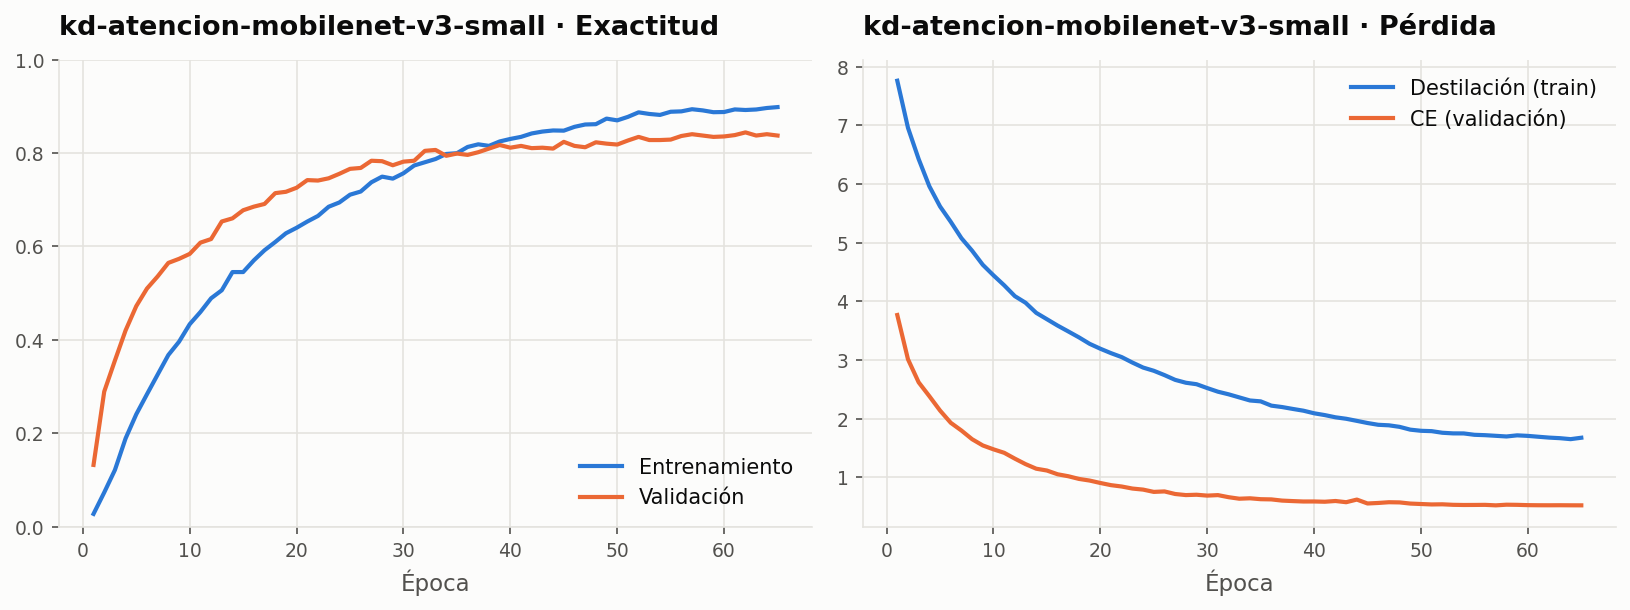

In [8]:
applyStyle()
import matplotlib.pyplot as plt

epocas = range(1, len(historia["loss"]) + 1)
figura, ejes = plt.subplots(1, 2, figsize=(11, 4.2))

ejes[0].plot(epocas, historia["accuracy"], color=SERIE_1, label="Entrenamiento")
ejes[0].plot(epocas, historia["val_accuracy"], color=SERIE_2, label="Validación")
ejes[0].set(title=f"{RUN_NAME} · Exactitud", xlabel="Época", ylim=(0, 1))
ejes[0].legend(loc="lower right")

ejes[1].plot(epocas, historia["loss"], color=SERIE_1, label="Destilación (train)")
ejes[1].plot(epocas, historia["val_loss"], color=SERIE_2, label="CE (validación)")
ejes[1].set(title=f"{RUN_NAME} · Pérdida", xlabel="Época")
ejes[1].legend(loc="upper right")

figura.tight_layout()
figura.savefig(IMGS / "training_history.png", bbox_inches="tight")
plt.show()

## 7 · Evaluación

In [9]:
metricas = {
    "test": evalStats.evaluar(estudiante, dsTest, clases),
    "validate": evalStats.evaluar(estudiante, dsVal, clases),
}

pd.DataFrame([
    {k: round(v, 4) if isinstance(v, float) else v
     for k, v in m.items()
     if k in ("num_samples", "accuracy", "top3_accuracy",
              "macro_f1", "weighted_f1", "macro_precision", "macro_recall")}
    for m in metricas.values()
], index=list(metricas.keys()))

2026-10-03 17:11:40.221907: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-10-03 17:11:46.134431: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,num_samples,accuracy,top3_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
test,2061,0.8345,0.9500,0.8321,0.8407,0.8301,0.8308
validate,1038,0.8401,0.9509,0.8464,0.8443,0.8341,0.8366


## 8 · ¿Sirvió la destilación?

Contra el mismo estudiante sin docente (su run de `01_student`) y contra el docente, que marca el techo.

In [10]:
# el control debe compartir arquitectura Y régimen: si no, se compararía
# contra el estudiante congelado y el efecto del fine-tuning se atribuiría a la KD
controlRun = next(
    (r for r in registro.listRuns()
     if r["architecture"] == ARQUITECTURA
     and not r.get("teacher_run_id")
     and r.get("finetuning", 0.0) == FRACCION_DESCONGELADA),
    None,
)
if controlRun is None:
    raise ValueError(
        f"Falta el control: {ARQUITECTURA} sin destilar con "
        f"FRACCION_DESCONGELADA={FRACCION_DESCONGELADA}. Córrelo en 01_student/01.")

filas = [{
    "modelo": "docente",
    "arquitectura": ARQUITECTURA_DOCENTE,
    "test_accuracy": docenteInfo["test_accuracy"],
    "test_macro_f1": docenteInfo["test_macro_f1"],
    "parametros": docente.count_params(),
}]
if controlRun:
    filas.append({
        "modelo": "control (sin KD)",
        "arquitectura": ARQUITECTURA,
        "test_accuracy": controlRun["test_accuracy"],
        "test_macro_f1": controlRun["test_macro_f1"],
        "parametros": estudiante.count_params(),
    })
else:
    print("Sin run de control registrado — corre antes 01_student")
filas.append({
    "modelo": "estudiante (KD)",
    "arquitectura": ARQUITECTURA,
    "test_accuracy": metricas["test"]["accuracy"],
    "test_macro_f1": metricas["test"]["macro_f1"],
    "parametros": estudiante.count_params(),
})

comparacion = pd.DataFrame(filas)
if controlRun:
    delta = metricas["test"]["macro_f1"] - controlRun["test_macro_f1"]
    brecha = docenteInfo["test_macro_f1"] - controlRun["test_macro_f1"]
    print(f"Delta macro-F1 por destilar: {delta:+.4f}")
    if brecha > 0:
        print(f"Recupera el {delta / brecha:.1%} de la brecha estudiante-docente")
comparacion

Delta macro-F1 por destilar: -0.0126
Recupera el -17.7% de la brecha estudiante-docente


,modelo,arquitectura,test_accuracy,test_macro_f1,parametros
0,docente,efficientnet_v2_s,0.914161,0.913467,21165231
1,control (sin KD),mobilenet_v3_small,0.846266,0.842630,1412543
2,estudiante (KD),mobilenet_v3_small,0.834546,0.830073,1412543


## 9 · Matriz de confusión

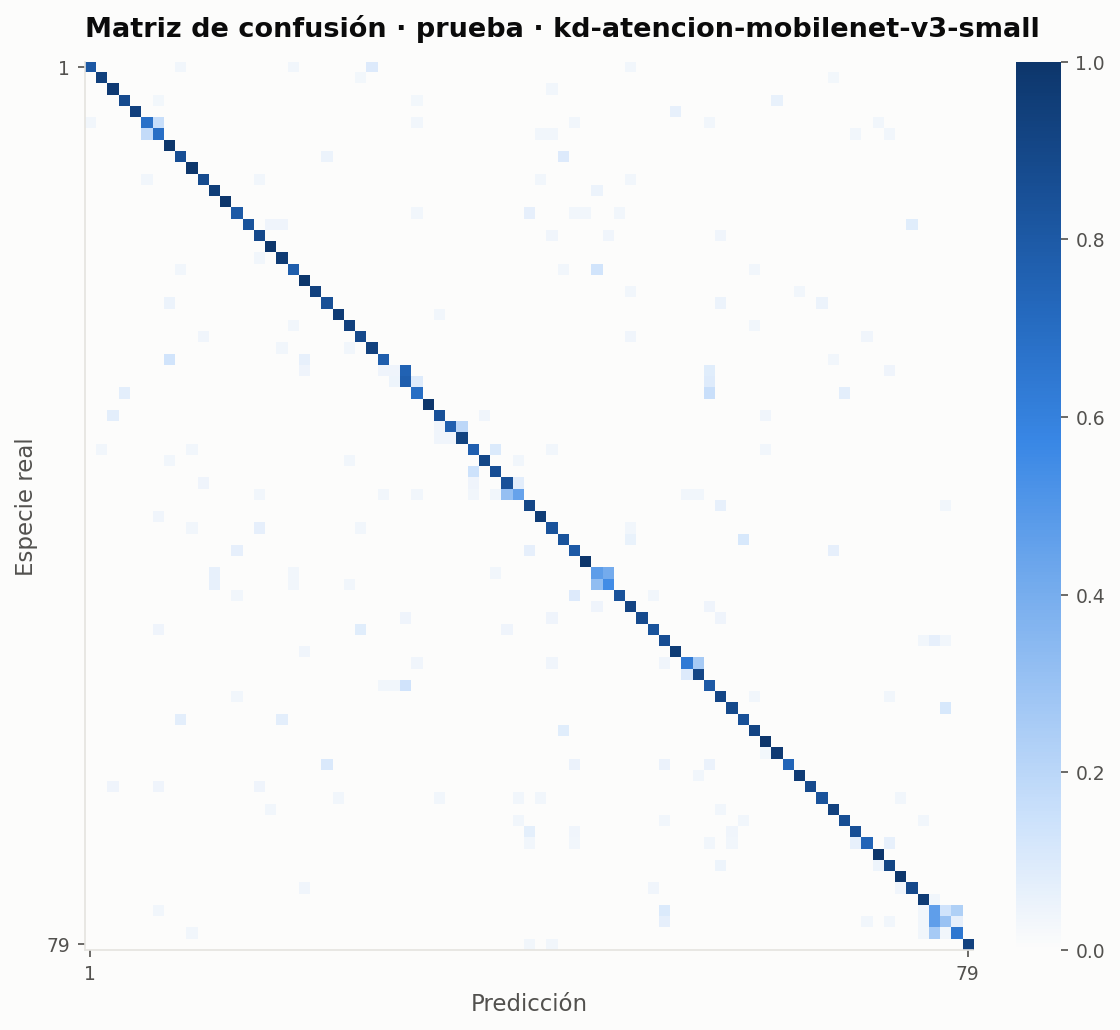

In [11]:
_ = plotConfusionMatrix(
    metricas["test"],
    f"Matriz de confusión · prueba · {RUN_NAME}",
)
plt.savefig(IMGS / "confusion_test.png", bbox_inches="tight")
plt.show()

## 10 · Confusiones principales

In [12]:
confusiones = evalStats.confusionesPrincipales(metricas["test"])
pd.DataFrame(confusiones).head(10)

,real,predicha,casos,tasa
0,eurema_arbela,eurema_xantochlora,18,0.750
1,urbanus_simplicius,urbanus_procne,14,0.467
2,mechanitis_lysimnia,mechanitis_menapis,13,0.406
3,mechanitis_menapis,mechanitis_lysimnia,10,0.323
4,heliconius_melpomene,heliconius_erato,9,0.310
5,urbanus_teleus,urbanus_procne,8,0.258
6,parides_erithalion,parides_eurimedes,7,0.259
7,urbanus_procne,urbanus_teleus,7,0.233
8,hamadryas_februa,hamadryas_feronia,5,0.192
9,archaeoprepona_demophon,archaeoprepona_amphimachus,5,0.172


## 11 · Versionado

In [13]:
estudiante.save(RUN_DIR / "model.keras")
registro.writeJson(RUN_DIR / "history.json", historia)
registro.writeJson(RUN_DIR / "metrics.json", {
    "run_id": RUN_ID,
    "class_names": clases,
    "splits": metricas,
    "top_confusions": {
        s: evalStats.confusionesPrincipales(m) for s, m in metricas.items()
    },
})

configuracion = {
    "run_id": RUN_ID,
    "name": RUN_NAME,
    "dataset_version": corpus.versionActual(),
    "architecture": ARQUITECTURA,
    "role": ROL,
    "notes": NOTAS,
    "num_classes": len(clases),
    "distillation": {
        "tipo": "atencion",
        "teacher_run_id": docenteInfo["run_id"],
        "teacher_architecture": ARQUITECTURA_DOCENTE,
        "temperatura": TEMPERATURA,
        "beta_atencion": BETA_ATENCION,
        "finetuning": FRACCION_DESCONGELADA,
        "alfa": ALFA,
    },
    "hyperparameters": {
        "img_size": list(TAMANO),
        "batch_size": LOTE,
        "epochs_budget": EPOCAS,
        "epochs_ran": len(historia["loss"]),
        "learning_rate": TASA_APRENDIZAJE,
        "early_stopping_patience": PACIENCIA,
        "class_weights": "balanced",
        "seed": SEMILLA,
        "backbone": f"{ARQUITECTURA}/imagenet (congelado)",
    },
    "environment": {
        "python": platform.python_version(),
        "tensorflow": tf.__version__,
        "platform": platform.platform(),
        "acelerador": next((d.device_type for d in tf.config.list_physical_devices()
                            if d.device_type != "CPU"), "cpu"),
    },
    "started_at": inicio.isoformat(),
    "finished_at": fin.isoformat(),
    "training_minutes": round((fin - inicio).total_seconds() / 60, 1),
}
registro.writeJson(RUN_DIR / "run.json", configuracion)

registro.registrar(RUN_ID)

if PROMOVER:
    registro.promoteRun(RUN_ID)

print(f"Run guardado en {RUN_DIR}")

if Path("/kaggle").exists():
    from scripts.kaggle import publicarRun

    publicarRun(RUN_ID)


Run guardado en /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling/outputs/runs/20261003T123506Z_kd-atencion-mobilenet-v3-small


## Resumen

In [14]:
pd.Series({
    "run_id": RUN_ID,
    "estudiante": ARQUITECTURA,
    "docente": ARQUITECTURA_DOCENTE,
    "temperatura": TEMPERATURA,
    "alfa": ALFA,
    "epocas": len(historia["loss"]),
    "minutos": configuracion["training_minutes"],
    "test_accuracy": round(metricas["test"]["accuracy"], 4),
    "test_top3": round(metricas["test"]["top3_accuracy"], 4),
    "test_macro_f1": round(metricas["test"]["macro_f1"], 4),
    "validate_accuracy": round(metricas["validate"]["accuracy"], 4),
    "validate_macro_f1": round(metricas["validate"]["macro_f1"], 4),
}).to_frame("valor")

,valor
run_id,20261003T123506Z_kd-atencion-mobilenet-v3-small
estudiante,mobilenet_v3_small
docente,efficientnet_v2_s
temperatura,4.0
alfa,0.7
epocas,65
minutos,576.3
test_accuracy,0.8345
test_top3,0.95
test_macro_f1,0.8301
